# IND320 Dashboard

Denne notebooken dokumenterer utviklingen og analysen i IND320-prosjektet.

## Lenker

- [GitHub-repository](https://github.com/Kaja321/ind320-dashboard-kaja321)
- [Publisert Streamlit-app](https://ind320-dashboard-kaja321-2mtfc3yvzqjjw6wtcwjukq.streamlit.app/)

## Bruk av kunstig intelligens

Jeg har brukt kunstig intelligens som støtte under utviklingen av prosjektet. KI har blant annet blitt brukt til å forklare Git, GitHub, Streamlit og prosjektstruktur, samt til feilsøking og forslag til forbedring av kode. Forslagene har blitt testet og vurdert før de ble tatt i bruk.

## Prosjektlogg

### Oppstart

Jeg opprettet først en egen prosjektmappe med en hovedfil for Streamlit, en requirements-fil og en gitignore-fil. Deretter opprettet jeg et offentlig repository på GitHub og koblet den lokale prosjektmappen til dette.

Jeg publiserte den første versjonen av appen på Streamlit Community Cloud. Etter dette opprettet jeg en struktur med fire sider: hovedside, tabellside, plottside og testside. Sidene ble testet lokalt før endringene ble lastet opp til GitHub.

## Dataanalyse

In [1]:
# Importerer bibliotekene som brukes i analysen
import pandas as pd               # innlesing og behandling av data
import matplotlib.pyplot as plt   # plotting

### Innlesing og oversikt

In [2]:
# Leser inn datasettet med fyllingsgrad i vannmagasiner
df = pd.read_csv("reservoirs.csv")

# Viser de første radene for å få et inntrykk av dataene
df.head()

,dato_Id,omrType,omrnr,iso_aar,iso_uke,fyllingsgrad,kapasitet_TWh,fylling_TWh,neste_Publiseringsdato,fyllingsgrad_forrige_uke,endring_fyllingsgrad
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


In [3]:
# Viser størrelsen på datasettet
print("Antall rader og kolonner:", df.shape)

# Viser datatyper og antall ikke-tomme verdier per kolonne
print("\nOversikt over kolonnene:")
df.info()

# Viser hvilke områdetyper og områdenumre som finnes, og antall rader for hver
print("\nAntall rader per område:")
print(df.groupby(["omrType", "omrnr"]).size())

Antall rader og kolonner: (14877, 11)

Oversikt over kolonnene:
<class 'pandas.DataFrame'>
RangeIndex: 14877 entries, 0 to 14876
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   dato_Id                   14877 non-null  str    
 1   omrType                   14877 non-null  str    
 2   omrnr                     14877 non-null  int64  
 3   iso_aar                   14877 non-null  int64  
 4   iso_uke                   14877 non-null  int64  
 5   fyllingsgrad              14877 non-null  float64
 6   kapasitet_TWh             14877 non-null  float64
 7   fylling_TWh               14877 non-null  float64
 8   neste_Publiseringsdato    14877 non-null  str    
 9   fyllingsgrad_forrige_uke  14877 non-null  float64
 10  endring_fyllingsgrad      14877 non-null  float64
dtypes: float64(5), int64(3), str(3)
memory usage: 1.7 MB

Antall rader per område:
omrType  omrnr
EL       1        1653
 

### Omdøping av kolonner

In [4]:
# Omdøper kolonnene til engelske og forståelige navn
df = df.rename(
    columns={
        "dato_Id": "date",
        "omrType": "area_type",
        "omrnr": "area_number",
        "iso_aar": "year",
        "iso_uke": "week",
        "fyllingsgrad": "fill_level",
        "kapasitet_TWh": "capacity_twh",
        "fylling_TWh": "stored_energy_twh",
        "neste_Publiseringsdato": "next_publication_date",
        "fyllingsgrad_forrige_uke": "previous_week_fill_level",
        "endring_fyllingsgrad": "change_in_fill_level",
    }
)
# Viser de første radene for å sjekke at kolonnene har fått nye navn
df.head()

,date,area_type,area_number,year,week,fill_level,capacity_twh,stored_energy_twh,next_publication_date,previous_week_fill_level,change_in_fill_level
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


In [5]:
# Viser statistikk (gjennomsnitt, min, maks osv.) for de numeriske kolonnene
df.describe()

,area_number,year,week,fill_level,capacity_twh,stored_energy_twh,previous_week_fill_level,change_in_fill_level
count,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000
mean,2.333333,2010.346038,26.405929,0.618852,29.145860,18.139713,0.618890,-0.000038
std,1.490762,9.146696,15.017910,0.214850,22.739070,15.966211,0.214843,0.031385
min,0.000000,1995.000000,1.000000,0.055160,6.003264,0.331142,0.055160,-0.242484
25%,1.000000,2002.000000,13.000000,0.456234,17.390587,7.321973,0.456356,-0.022395
50%,2.000000,2010.000000,26.000000,0.648049,23.237715,14.501389,0.648114,-0.007072
75%,3.000000,2018.000000,39.000000,0.802135,34.043590,22.203530,0.802133,0.016277
max,5.000000,2026.000000,53.000000,1.020072,87.437580,84.544820,1.020037,0.336623


### Filtrering

In [6]:
# Gjør date om til datoformat
df["date"] = pd.to_datetime(df["date"])

# Plukker ut radene for strømprisområde NO1 (altså area_type "EL" OG area_number 1)
# Til slutt sorteres radene etter dato, fra eldst til nyest.
df_plot = df[(df["area_type"] == "EL") & (df["area_number"] == 1)].sort_values("date")

### Plott av hver variabel

Datasettet inneholder målinger for flere områder samtidig: fem strømprisområder (NO1–NO5), tre VASS-områder og hele landet. For å få en ren tidsserie plottes ett område om gangen. Jeg har valgt strømprisområde NO1 (Østlandet) som eksempel, men den samme analysen kan gjøres for de andre områdene ved å endre filtreringen.

Jeg plotter alle kolonnene som inneholder måleverdier: `fill_level`, `stored_energy_twh`, `capacity_twh`, `previous_week_fill_level` og `change_in_fill_level`. De øvrige kolonnene plottes ikke fordi de ikke er målinger:

- `area_type` og `area_number` angir hvilket område raden gjelder, og er konstante etter filtreringen
- `year` og `week` er deler av datoen, som allerede brukes på x-aksen
- `next_publication_date` er en publiseringsdato og sier ikke noe om magasinene

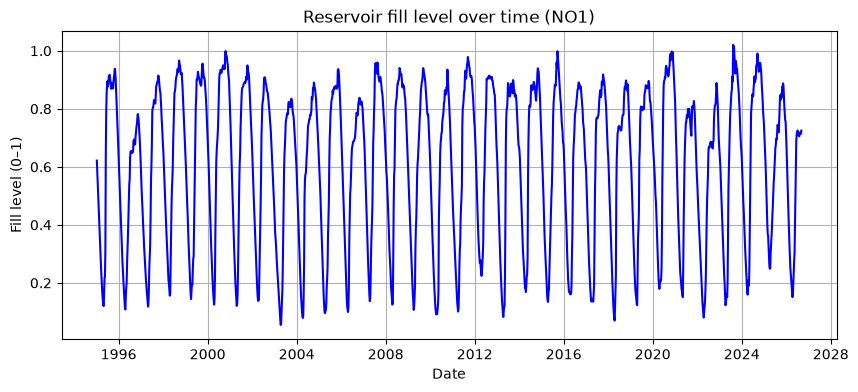

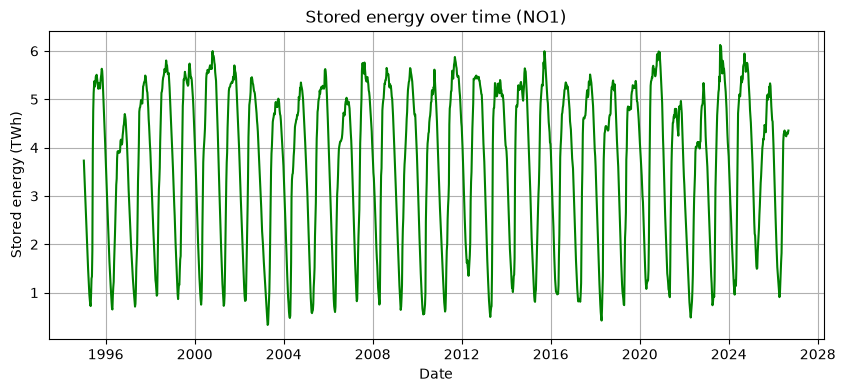

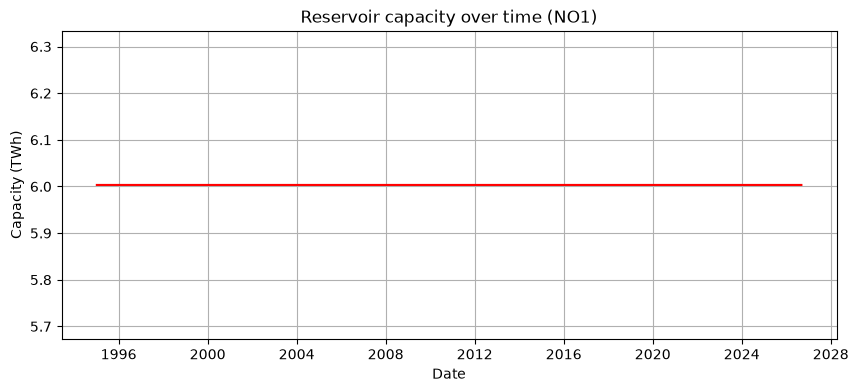

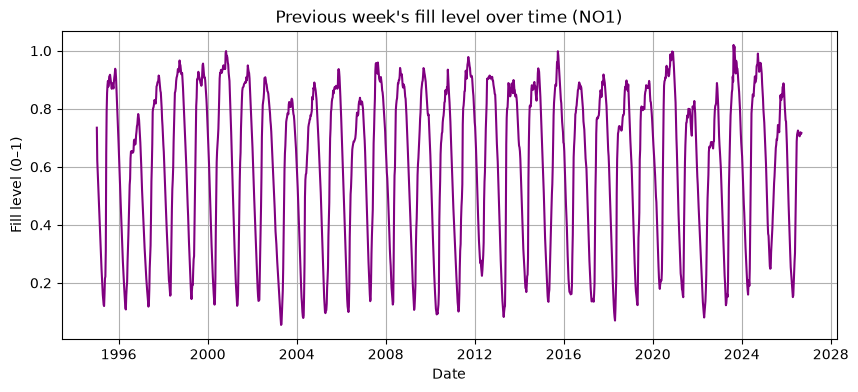

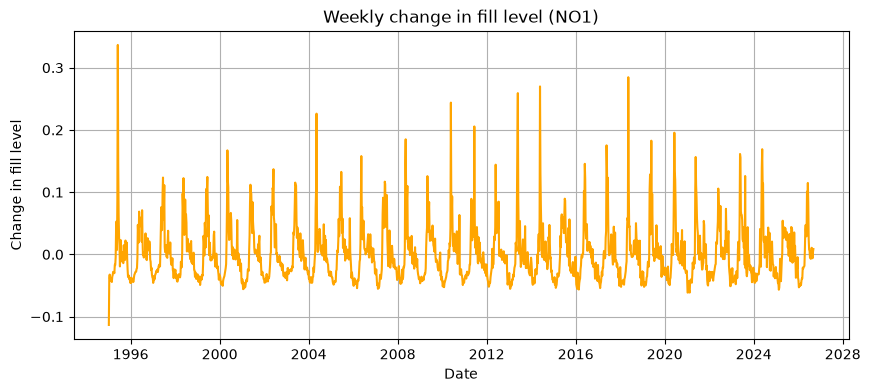

In [7]:
# Plotter hver variabel i en egen figur for strømprisområde NO1.
# Hver figur har tittel, aksetitler og rutenett for å gjøre den lett å lese.

# Fyllingsgrad
plt.figure(figsize=(10, 4))
plt.plot(df_plot["date"], df_plot["fill_level"], color="blue")
plt.title("Reservoir fill level over time (NO1)")
plt.xlabel("Date")
plt.ylabel("Fill level (0–1)")
plt.grid(True)
plt.show()

# Lagret energi
plt.figure(figsize=(10, 4))
plt.plot(df_plot["date"], df_plot["stored_energy_twh"], color="green")
plt.title("Stored energy over time (NO1)")
plt.xlabel("Date")
plt.ylabel("Stored energy (TWh)")
plt.grid(True)
plt.show()

# Kapasitet
plt.figure(figsize=(10, 4))
plt.plot(df_plot["date"], df_plot["capacity_twh"], color="red")
plt.title("Reservoir capacity over time (NO1)")
plt.xlabel("Date")
plt.ylabel("Capacity (TWh)")
plt.grid(True)
plt.show()

# Fyllingsgrad forrige uke
plt.figure(figsize=(10, 4))
plt.plot(df_plot["date"], df_plot["previous_week_fill_level"], color="purple")
plt.title("Previous week's fill level over time (NO1)")
plt.xlabel("Date")
plt.ylabel("Fill level (0–1)")
plt.grid(True)
plt.show()

# Endring i fyllingsgrad fra forrige uke
plt.figure(figsize=(10, 4))
plt.plot(df_plot["date"], df_plot["change_in_fill_level"], color="orange")
plt.title("Weekly change in fill level (NO1)")
plt.xlabel("Date")
plt.ylabel("Change in fill level")
plt.grid(True)
plt.show()

Plottene viser et tydelig sesongmønster: magasinene er lavest på våren og fylles raskt opp når snøen smelter, som gir de store positive toppene i ukentlig endring. Kapasiteten i NO1 er konstant på ca. 6 TWh gjennom hele perioden, så lagret energi følger samme mønster som fyllingsgraden. Fyllingsgraden forrige uke er den samme serien forskjøvet én uke, og brukes til å beregne ukentlig endring. Fyllingsgraden går så vidt over 1.0 enkelte år, noe som trolig skyldes målefeil eller avrunding.

### Fellesplott

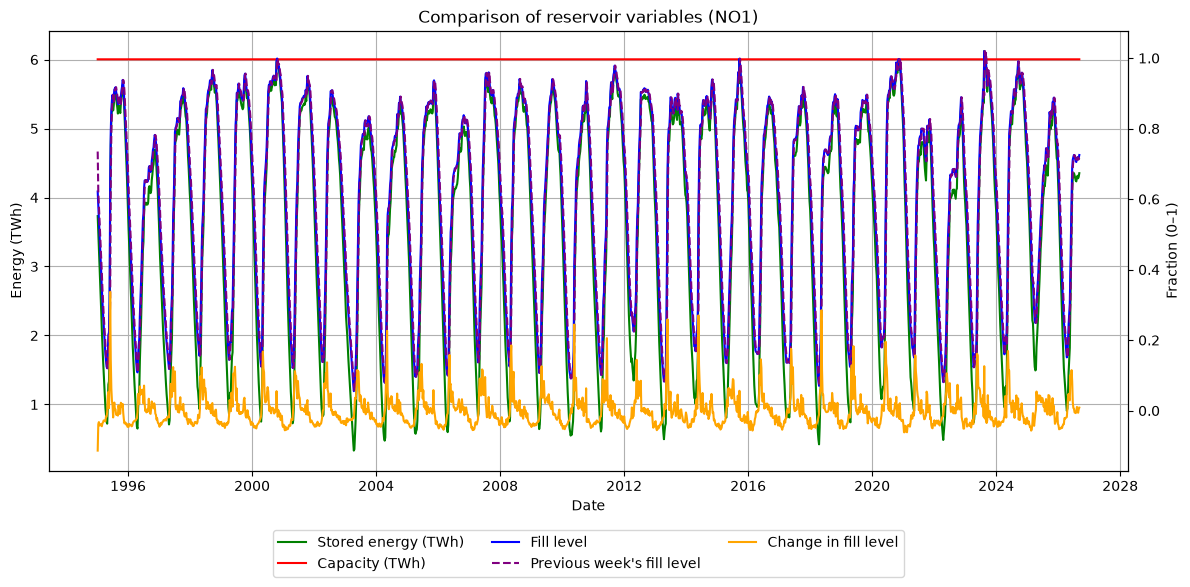

In [8]:
# Plotter alle måleverdiene i samme figur for strømprisområde NO1.
# Variablene har ulike enheter og skalaer, så de fordeles på to y-akser:
# venstre akse for energi (TWh), høyre akse for andeler (0–1).

fig, ax1 = plt.subplots(figsize=(12, 6))

# Venstre akse: variabler målt i TWh
ax1.plot(df_plot["date"], df_plot["stored_energy_twh"], color="green", label="Stored energy (TWh)")
ax1.plot(df_plot["date"], df_plot["capacity_twh"], color="red", label="Capacity (TWh)")
ax1.set_xlabel("Date")
ax1.set_ylabel("Energy (TWh)")
ax1.grid(True)

# Høyre akse: variabler som er andeler (fyllingsgrad og endring)
ax2 = ax1.twinx()
ax2.plot(df_plot["date"], df_plot["fill_level"], color="blue", label="Fill level")
ax2.plot(df_plot["date"], df_plot["previous_week_fill_level"], color="purple", linestyle="--", label="Previous week's fill level")
ax2.plot(df_plot["date"], df_plot["change_in_fill_level"], color="orange", label="Change in fill level")
ax2.set_ylabel("Fraction (0–1)")

# Samler linjene og navnene fra begge aksene, slik at de kan vises i én felles forklaring
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

# Legger forklaringen under plottet, slik at den ikke dekker dataene
ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),   # plasserer boksen midt under figuren
    ncol=3,                        # fordeler navnene på tre kolonner
)

plt.title("Comparison of reservoir variables (NO1)")
plt.tight_layout()
plt.show()

### Sammenligning av skalaer

Variablene har ulike enheter og skalaer. Lagret energi og kapasitet måles i TWh (ca. 0–6 for NO1), mens fyllingsgrad og endring i fyllingsgrad er andeler mellom ca. -0.1 og 1. På én felles akse ville andelene blitt nesten flate. Derfor bruker jeg to y-akser: TWh på venstre side og andeler på høyre side.

Lagret energi og fyllingsgrad ligger nesten oppå hverandre fordi kapasiteten er konstant. Lagret energi er da bare fyllingsgraden ganget med 6 TWh. Ukentlig endring viser tydelige topper hver vår, når snøsmeltingen fyller magasinene.